# Notebook 4 — NL2SQL2NL com LangGraph

Implementação de um fluxo robusto usando LangGraph com:
- **Planejamento**: LLM identifica tabelas e joins necessários
- **Geração**: LLM gera a SQL baseada no plano
- **Validação**: Sistema bloqueia comandos perigosos (não-SELECT)
- **Execução**: Postgres executa a SQL
- **Retry**: Até 3 tentativas de correção automática em caso de erro
- **Resposta Natural**: LLM transforma resultados em português

O fluxo do grafo é:
```
START → carregar_dicionario → planejar_sql → gerar_sql → validar_sql → executar_sql
                                                                              ↓
                                                                 decidir_proximo_passo
                                                                 /     |     \
                                            gerar_resposta /  corrigir_sql  \  falha
                                                        ↓     ↙       ↓       ↘
                                                       END   validar_sql    END
```

## 1. Setup — Importações e paths

In [1]:
import os, sys, re, yaml, json
from pathlib import Path
from typing import TypedDict, Literal
from IPython.display import display

projeto_raiz = Path(os.getcwd()).parent
sys.path.insert(0, str(projeto_raiz / "src"))
print(f"✓ Path configurado: {sys.path[0]}")

✓ Path configurado: /home/jovyan/work/src


In [2]:
from nl2sql2nl.config import OPENAI_API_KEY, POSTGRES_HOST, POSTGRES_PORT, POSTGRES_DB
from nl2sql2nl.database import executar_consulta
from nl2sql2nl.llm import chamar_modelo
from nl2sql2nl.logger import obter_logger
from langgraph.graph import StateGraph, END

logger = obter_logger(__name__)
print("✓ Módulos importados com sucesso!")

/opt/conda/lib/python3.11/site-packages/langgraph/cache/base/__init__.py:8: LangChainPendingDeprecationWarning: The default value of `allowed_objects` will change in a future version. Pass an explicit value (e.g., allowed_objects='messages' or allowed_objects='core') to suppress this warning.
  from langgraph.checkpoint.serde.jsonplus import JsonPlusSerializer


2026-05-26 21:04:47 | INFO | nl2sql2nl.config | Configurações carregadas com sucesso.
✓ Módulos importados com sucesso!


## 2. Definição do estado

In [3]:
class EstadoNL2SQL(TypedDict):
    pergunta: str
    dicionario_dados: dict
    plano_sql: str
    sql_gerado: str
    resultado_sql: list
    erro_sql: str | None
    tentativas: int
    max_tentativas: int
    resposta_final: str

print("✓ Estado do grafo definido")

✓ Estado do grafo definido


## 3. Funções utilitárias

In [4]:
def limpar_sql(sql_bruta: str) -> str:
    sql = sql_bruta.strip()
    sql = re.sub(r'^```(?:sql|SQL)?\n?', '', sql)
    sql = re.sub(r'\n?```$', '', sql)
    return sql.strip()

def formatar_dicionario_para_prompt(dicionario: dict) -> str:
    linhas = ["=== DICIONÁRIO DE DADOS MIMIC FHIR ===", ""]
    for tabela in dicionario['tabelas']:
        linhas.append(f"Tabela: {tabela['nome']}")
        linhas.append(f"Descrição: {tabela.get('descricao', 'N/A')}")
        linhas.append("Colunas:")
        for coluna in tabela['colunas']:
            pk = "[PK]" if coluna.get('chave_primaria') else ""
            fk = f"[FK: {coluna.get('chave_estrangeira')}]" if coluna.get('chave_estrangeira') else ""
            linhas.append(f"  - {coluna['nome']} ({coluna['tipo']}) {pk} {fk}")
            linhas.append(f"    {coluna.get('descricao', 'N/A')}")
        linhas.append("")
    return "\n".join(linhas)

print("✓ Funções utilitárias definidas")

✓ Funções utilitárias definidas


## 4. Nós do grafo

In [5]:
def carregar_dicionario(estado: EstadoNL2SQL) -> EstadoNL2SQL:
    logger.info("[1/9] Carregando dicionário de dados...")
    caminho = projeto_raiz / "dic" / "dicionario_dados.yaml"
    with open(caminho, 'r', encoding='utf-8') as f:
        estado['dicionario_dados'] = yaml.safe_load(f)
    num_tabelas = len(estado['dicionario_dados']['tabelas'])
    logger.info(f"[1/9] ✓ Dicionário carregado: {num_tabelas} tabelas")
    return estado

def planejar_sql(estado: EstadoNL2SQL) -> EstadoNL2SQL:
    logger.info("[2/9] Planejando SQL...")
    contexto = formatar_dicionario_para_prompt(estado['dicionario_dados'])
    prompt = f"""Você é um especialista em MIMIC FHIR.
Pergunta: {estado['pergunta']}
{contexto}
Descreva UM parágrafo: quais tabelas, joins e filtros são necessários."""
    try:
        estado['plano_sql'] = chamar_modelo(prompt, modelo="gpt-5-nano").strip()
        logger.info("[2/9] ✓ Plano criado")
    except Exception as e:
        estado['erro_sql'] = f"Erro ao planejar: {e}"
        logger.error(f"[2/9] ✗ {estado['erro_sql']}")
    return estado

def gerar_sql(estado: EstadoNL2SQL) -> EstadoNL2SQL:
    logger.info("[3/9] Gerando SQL...")
    if estado['erro_sql']:
        logger.error(f"[3/9] Pulando (erro anterior): {estado['erro_sql']}")
        return estado
    contexto = formatar_dicionario_para_prompt(estado['dicionario_dados'])
    prompt = f"""Você é especialista em SQL PostgreSQL.
Plano: {estado['plano_sql']}
Pergunta: {estado['pergunta']}
{contexto}
Gere APENAS a SQL SELECT (sem explicações). Retorne APENAS a SQL."""
    try:
        sql_bruta = chamar_modelo(prompt, modelo="gpt-5-nano")
        estado['sql_gerado'] = limpar_sql(sql_bruta)
        logger.info("[3/9] ✓ SQL gerada")
    except Exception as e:
        estado['erro_sql'] = f"Erro ao gerar SQL: {e}"
        logger.error(f"[3/9] ✗ {estado['erro_sql']}")
    return estado

def validar_sql(estado: EstadoNL2SQL) -> EstadoNL2SQL:
    logger.info("[4/9] Validando SQL...")
    sql = estado['sql_gerado'].strip()
    if not sql:
        estado['erro_sql'] = "SQL vazia"
    elif not sql.upper().startswith('SELECT'):
        estado['erro_sql'] = "Apenas SELECT permitido"
    elif ';' in sql[:-1]:
        estado['erro_sql'] = "Múltiplas queries não permitidas"
    else:
        for palavra in ['DROP', 'DELETE', 'INSERT', 'UPDATE', 'CREATE', 'ALTER', 'TRUNCATE']:
            if f" {palavra} " in f" {sql.upper()} ":
                estado['erro_sql'] = f"Comando {palavra} bloqueado"
                break
    if estado['erro_sql']:
        logger.error(f"[4/9] ✗ {estado['erro_sql']}")
    else:
        logger.info("[4/9] ✓ SQL validada")
    return estado

def executar_sql(estado: EstadoNL2SQL) -> EstadoNL2SQL:
    logger.info("[5/9] Executando SQL...")
    if estado['erro_sql']:
        logger.error(f"[5/9] SQL inválida, pulando")
        return estado
    try:
        estado['resultado_sql'] = executar_consulta(estado['sql_gerado'])
        estado['erro_sql'] = None
        logger.info(f"[5/9] ✓ SQL executada ({len(estado['resultado_sql'])} linhas)")
    except Exception as e:
        estado['erro_sql'] = f"Erro Postgres: {str(e)}"
        estado['resultado_sql'] = []
        logger.error(f"[5/9] ✗ {estado['erro_sql']}")
    return estado

print("✓ Nós 1-5 definidos")

✓ Nós 1-5 definidos


In [6]:
def decidir_proximo_passo(estado: EstadoNL2SQL) -> Literal['gerar_resposta_natural', 'corrigir_sql', 'falha_controlada']:
    if estado['erro_sql'] is None:
        logger.info("[6/9] → gerar_resposta_natural")
        return 'gerar_resposta_natural'
    if estado['tentativas'] >= estado['max_tentativas']:
        logger.info(f"[6/9] → falha_controlada (tentativas esgotadas)")
        return 'falha_controlada'
    logger.info(f"[6/9] → corrigir_sql (tentativa {estado['tentativas'] + 1})")
    return 'corrigir_sql'

def corrigir_sql(estado: EstadoNL2SQL) -> EstadoNL2SQL:
    estado['tentativas'] += 1
    logger.info(f"[7/9] Corrigindo SQL (tentativa {estado['tentativas']})...")
    contexto = formatar_dicionario_para_prompt(estado['dicionario_dados'])
    prompt = f"""Você é especialista SQL.
SQL anterior: {estado['sql_gerado']}
Erro: {estado['erro_sql']}
Pergunta: {estado['pergunta']}
{contexto}
Corrija a SQL. Retorne APENAS a SQL."""
    try:
        sql_bruta = chamar_modelo(prompt, modelo="gpt-5-nano")
        estado['sql_gerado'] = limpar_sql(sql_bruta)
        logger.info("[7/9] ✓ SQL corrigida")
    except Exception as e:
        estado['erro_sql'] = f"Erro ao corrigir: {e}"
        logger.error(f"[7/9] ✗ {estado['erro_sql']}")
    return estado

def gerar_resposta_natural(estado: EstadoNL2SQL) -> EstadoNL2SQL:
    logger.info("[8/9] Gerando resposta...")
    resultados_str = ""
    if estado['resultado_sql']:
        for i, linha in enumerate(estado['resultado_sql'][:5], 1):
            resultados_str += f"Linha {i}: {linha}\n"
        if len(estado['resultado_sql']) > 5:
            resultados_str += f"... ({len(estado['resultado_sql'])} linhas total)\n"
    else:
        resultados_str = "(Nenhum resultado)"
    prompt = f"""Converta para português natural:
Pergunta: {estado['pergunta']}
SQL: {estado['sql_gerado']}
Resultados:\n{resultados_str}
Resposta em português:"""
    try:
        estado['resposta_final'] = chamar_modelo(prompt, modelo="gpt-5-nano").strip()
        logger.info("[8/9] ✓ Resposta gerada")
    except Exception as e:
        estado['resposta_final'] = f"Erro: {e}"
        logger.error(f"[8/9] ✗ Erro ao gerar resposta")
    return estado

def falha_controlada(estado: EstadoNL2SQL) -> EstadoNL2SQL:
    logger.info(f"[9/9] Falha após {estado['tentativas']} tentativas")
    estado['resposta_final'] = f"❌ Não consegui gerar a SQL após {estado['tentativas']} tentativas.\nÚltimo erro: {estado['erro_sql']}\nSQL: {estado['sql_gerado']}"
    return estado

print("✓ Nós 6-9 definidos")

✓ Nós 6-9 definidos


## 5. Construir e compilar o grafo

In [7]:
grafo = StateGraph(EstadoNL2SQL)
grafo.add_node("carregar_dicionario", carregar_dicionario)
grafo.add_node("planejar_sql", planejar_sql)
grafo.add_node("gerar_sql", gerar_sql)
grafo.add_node("validar_sql", validar_sql)
grafo.add_node("executar_sql", executar_sql)
grafo.add_node("corrigir_sql", corrigir_sql)
grafo.add_node("gerar_resposta_natural", gerar_resposta_natural)
grafo.add_node("falha_controlada", falha_controlada)

grafo.set_entry_point("carregar_dicionario")
grafo.add_edge("carregar_dicionario", "planejar_sql")
grafo.add_edge("planejar_sql", "gerar_sql")
grafo.add_edge("gerar_sql", "validar_sql")
grafo.add_edge("validar_sql", "executar_sql")
grafo.add_edge("corrigir_sql", "validar_sql")
grafo.add_edge("gerar_resposta_natural", END)
grafo.add_edge("falha_controlada", END)
grafo.add_conditional_edges(
    "executar_sql",
    decidir_proximo_passo,
    {"gerar_resposta_natural": "gerar_resposta_natural", "corrigir_sql": "corrigir_sql", "falha_controlada": "falha_controlada"}
)

pipeline = grafo.compile()
logger.info("✓ Grafo LangGraph compilado")
print("✓ Pipeline pronto!")

2026-05-26 21:04:47 | INFO | __main__ | ✓ Grafo LangGraph compilado
✓ Pipeline pronto!


## 6. Visualizar o grafo


DIAGRAMA DO GRAFO (Mermaid)



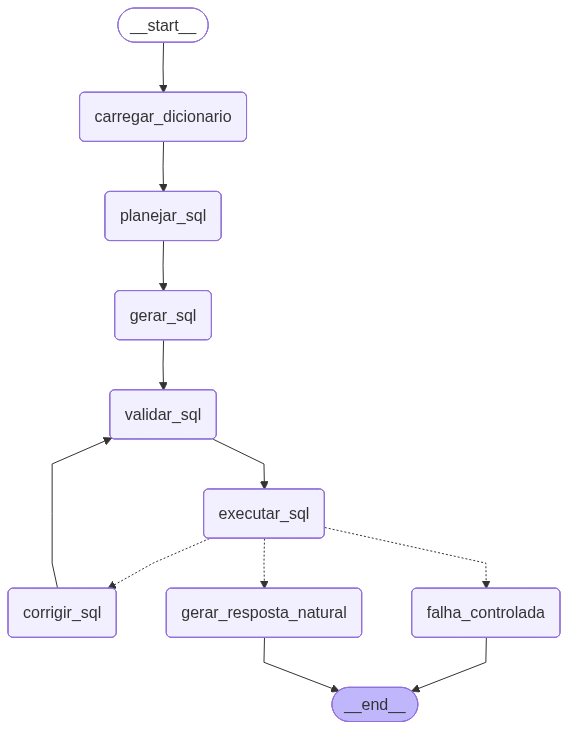

In [8]:
print("\n" + "="*80)
print("DIAGRAMA DO GRAFO (Mermaid)")
print("="*80 + "\n")
try:
    from IPython.display import Image, display
    display(Image(pipeline.get_graph().draw_mermaid_png()))
except Exception as e:
    print(f"PNG não disponível. Exibindo Mermaid:\n")
    print(pipeline.get_graph().draw_mermaid())
print("\n" + "="*80)

## 7. Teste com pergunta de referência

In [9]:
pergunta_teste = "Quais são os períodos dos encontros, períodos das localizações e nomes das localizações do paciente com identificador 10000032?"

print("\n" + "="*80)
print("TESTE 1: Pergunta de referência")
print("="*80)
print(f"\nPergunta: {pergunta_teste}")
print(f"\nIniciando pipeline...\n")

estado_inicial: EstadoNL2SQL = {
    'pergunta': pergunta_teste,
    'dicionario_dados': {},
    'plano_sql': '',
    'sql_gerado': '',
    'resultado_sql': [],
    'erro_sql': None,
    'tentativas': 0,
    'max_tentativas': 3,
    'resposta_final': ''
}

resultado = pipeline.invoke(estado_inicial)
print(f"\n" + "="*80)


TESTE 1: Pergunta de referência

Pergunta: Quais são os períodos dos encontros, períodos das localizações e nomes das localizações do paciente com identificador 10000032?

Iniciando pipeline...

2026-05-26 21:04:47 | INFO | __main__ | [1/9] Carregando dicionário de dados...
2026-05-26 21:04:47 | INFO | __main__ | [1/9] ✓ Dicionário carregado: 7 tabelas
2026-05-26 21:04:47 | INFO | __main__ | [2/9] Planejando SQL...
2026-05-26 21:04:47 | INFO | nl2sql2nl.llm | Enviando pergunta ao modelo 'gpt-5-nano'.
2026-05-26 21:04:47 | INFO | nl2sql2nl.llm | Criando modelo LLM: gpt-5-nano (temperatura=0.0)
2026-05-26 21:05:00 | INFO | nl2sql2nl.llm | Resposta recebida com 549 caracteres.
2026-05-26 21:05:00 | INFO | __main__ | [2/9] ✓ Plano criado
2026-05-26 21:05:00 | INFO | __main__ | [3/9] Gerando SQL...
2026-05-26 21:05:00 | INFO | nl2sql2nl.llm | Enviando pergunta ao modelo 'gpt-5-nano'.
2026-05-26 21:05:00 | INFO | nl2sql2nl.llm | Criando modelo LLM: gpt-5-nano (temperatura=0.0)
2026-05-26 21

## 8. Exibir resultados (teste 1)

In [10]:
import pandas as pd

print("\n" + "="*80)
print("RESULTADOS FINAIS (Pergunta de Referência)")
print("="*80)

print(f"\n📝 PERGUNTA:\n{resultado['pergunta']}")
print(f"\n📋 PLANO:\n{resultado['plano_sql']}")
print(f"\n🔍 SQL GERADA:\n{resultado['sql_gerado']}")

print(f"\n📊 RESULTADOS:")
if resultado['resultado_sql']:
    df = pd.DataFrame(resultado['resultado_sql'])
    print(f"Total: {len(df)} linhas\n")
    display(df)
else:
    print("Nenhum resultado.")

print(f"\n💬 RESPOSTA FINAL:\n{resultado['resposta_final']}")
print(f"\n📈 ESTATÍSTICAS: Tentativas {resultado['tentativas']}/{resultado['max_tentativas']}")
print("="*80)


RESULTADOS FINAIS (Pergunta de Referência)

📝 PERGUNTA:
Quais são os períodos dos encontros, períodos das localizações e nomes das localizações do paciente com identificador 10000032?

📋 PLANO:
Para obter isso, envolva as tabelas: pacientes (p), encontros (e), encontros_localizacoes (el) e localizacoes (l). Junte p.id a e.paciente_id, e e.id a el.encontro_id, e el.localizacao_id a l.id. Aplique o filtro p.identificador = '10000032' para selecionar o paciente desejado. Do resultado, retorne: e.periodo_inicio e e.periodo_fim (período do encontro), el.periodo_inicio e el.periodo_fim (período da localização dentro do encontro) e l.nome (nome da localização). Opcionalmente ordene por e.periodo_inicio para visualizar em sequência temporal.

🔍 SQL GERADA:
SELECT
  e.periodo_inicio,
  e.periodo_fim,
  el.periodo_inicio,
  el.periodo_fim,
  l.nome
FROM pacientes p
JOIN encontros e ON p.id = e.paciente_id
JOIN encontros_localizacoes el ON e.id = el.encontro_id
JOIN localizacoes l ON el.localiza

,periodo_inicio,periodo_fim,nome
0,2180-05-06 19:17:00,2180-05-06 23:30:00,Emergency Department
1,2180-05-06 23:30:00,2180-05-07 17:21:27,Transplant
2,2180-06-26 15:54:00,2180-06-26 21:31:00,Emergency Department
3,2180-06-26 21:31:00,2180-06-27 18:49:12,Transplant
4,2180-07-23 23:50:47,2180-07-24 19:52:58,Transplant
5,2180-07-22 16:24:00,2180-07-23 05:54:00,Emergency Department
6,2180-07-23 14:00:00,2180-07-23 23:50:47,Medical Intensive Care Unit (MICU)
7,2180-08-06 01:44:00,2180-08-07 17:50:44,Transplant
8,2180-08-05 20:58:00,2180-08-06 01:44:00,Emergency Department



💬 RESPOSTA FINAL:
Aqui estão os períodos solicitados para o paciente com identificador 10000032, conforme os registros apresentados (há 9 linhas no total, mas mostramos apenas as primeiras 5 aqui):

- Registro 1
  - Encontro: início 06/05/2180 19:17, fim 06/05/2180 23:30
  - Período da localização: 06/05/2180 19:17 a 06/05/2180 23:30
  - Localização: Emergency Department

- Registro 2
  - Encontro: início 06/05/2180 23:30, fim 07/05/2180 17:21:27
  - Período da localização: 06/05/2180 23:30 a 07/05/2180 17:21:27
  - Localização: Transplant

- Registro 3
  - Encontro: início 26/06/2180 15:54, fim 26/06/2180 21:31
  - Período da localização: 26/06/2180 15:54 a 26/06/2180 21:31
  - Localização: Emergency Department

- Registro 4
  - Encontro: início 26/06/2180 21:31, fim 27/06/2180 18:49:12
  - Período da localização: 26/06/2180 21:31 a 27/06/2180 18:49:12
  - Localização: Transplant

- Registro 5
  - Encontro: início 23/07/2180 23:50:47, fim 24/07/2180 19:52:58
  - Período da localizaçã

## 9. Teste com pergunta adicional complexa

In [11]:
pergunta_complexa = "Quais são os nomes dos procedimentos realizados no paciente com identificador 10000032? Retornar as datas dos eventos. E quais são os diagnósticos deste paciente?"

print("\n" + "="*80)
print("TESTE 2: Pergunta Complexa com Múltiplas Entidades")
print("="*80)
print(f"\nPergunta: {pergunta_complexa}")
print(f"\nIniciando pipeline...\n")

estado_inicial_2: EstadoNL2SQL = {
    'pergunta': pergunta_complexa,
    'dicionario_dados': {},
    'plano_sql': '',
    'sql_gerado': '',
    'resultado_sql': [],
    'erro_sql': None,
    'tentativas': 0,
    'max_tentativas': 3,
    'resposta_final': ''
}

resultado_2 = pipeline.invoke(estado_inicial_2)
print(f"\n" + "="*80)


TESTE 2: Pergunta Complexa com Múltiplas Entidades

Pergunta: Quais são os nomes dos procedimentos realizados no paciente com identificador 10000032? Retornar as datas dos eventos. E quais são os diagnósticos deste paciente?

Iniciando pipeline...

2026-05-26 21:05:35 | INFO | __main__ | [1/9] Carregando dicionário de dados...
2026-05-26 21:05:35 | INFO | __main__ | [1/9] ✓ Dicionário carregado: 7 tabelas
2026-05-26 21:05:35 | INFO | __main__ | [2/9] Planejando SQL...
2026-05-26 21:05:35 | INFO | nl2sql2nl.llm | Enviando pergunta ao modelo 'gpt-5-nano'.
2026-05-26 21:05:35 | INFO | nl2sql2nl.llm | Criando modelo LLM: gpt-5-nano (temperatura=0.0)
2026-05-26 21:05:48 | INFO | nl2sql2nl.llm | Resposta recebida com 1009 caracteres.
2026-05-26 21:05:48 | INFO | __main__ | [2/9] ✓ Plano criado
2026-05-26 21:05:48 | INFO | __main__ | [3/9] Gerando SQL...
2026-05-26 21:05:48 | INFO | nl2sql2nl.llm | Enviando pergunta ao modelo 'gpt-5-nano'.
2026-05-26 21:05:48 | INFO | nl2sql2nl.llm | Criando

## 10. Exibir resultados (teste 2)

In [12]:
print("\n" + "="*80)
print("RESULTADOS FINAIS (Pergunta Complexa)")
print("="*80)

print(f"\n📝 PERGUNTA:\n{resultado_2['pergunta']}")
print(f"\n📋 PLANO:\n{resultado_2['plano_sql']}")
print(f"\n🔍 SQL GERADA:\n{resultado_2['sql_gerado']}")

print(f"\n📊 RESULTADOS:")
if resultado_2['resultado_sql']:
    df_2 = pd.DataFrame(resultado_2['resultado_sql'])
    print(f"Total: {len(df_2)} linhas\n")
    display(df_2)
else:
    print("Nenhum resultado.")

print(f"\n💬 RESPOSTA FINAL:\n{resultado_2['resposta_final']}")
print(f"\n📈 ESTATÍSTICAS: Tentativas {resultado_2['tentativas']}/{resultado_2['max_tentativas']}")
print("\n" + "="*80)
print("✓ Pipeline NL2SQL2NL com LangGraph testado com sucesso!")
print("="*80)


RESULTADOS FINAIS (Pergunta Complexa)

📝 PERGUNTA:
Quais são os nomes dos procedimentos realizados no paciente com identificador 10000032? Retornar as datas dos eventos. E quais são os diagnósticos deste paciente?

📋 PLANO:
Para obter as informações solicitadas, use as tabelas e junções a seguir em um único conjunto de consultas: partir de pacientes para localizar o registro do paciente com identificador = '10000032' (pacientes.identificador); em seguida, junte procedimentos (procedimentos.paciente_id = pacientes.id) para recuperar code_display (nome do procedimento) e performed_date_time (data/hora do procedimento); para os diagnósticos, junte condicoes (condicoes.paciente_id = pacientes.id) para obter code_display (descrição do diagnóstico) e, se quiser associar aos episódios, utilize condicoes.encontro_id e junte com encontros (encontros.id) para acessar periodo_inicio/periodo_fim. Filtros adicionais podem incluir procedimentos.status (p.ex., excluir CANCELLED) e um intervalo de te

## 11. Teste de segurança — Validação contra comandos perigosos

In [ ]:
print("\n" + "="*80)
print("TESTES DE SEGURANÇA — Validação contra comandos perigosos")
print("="*80)
print("\nTestando que comandos INSERT, UPDATE, DELETE, DROP, ALTER, CREATE e TRUNCATE")
print("são bloqueados pela função validar_sql().\n")

# Casos de teste com comandos perigosos
test_cases = [
    ("INSERT INTO pacientes VALUES ('123', 'Test')", "INSERT", True),
    ("INSERT INTO pacientes (id, nome) SELECT id, nome FROM temp", "INSERT with SELECT", True),
    ("UPDATE pacientes SET nome = 'novo' WHERE id = '123'", "UPDATE", True),
    ("DELETE FROM pacientes WHERE id = '123'", "DELETE", True),
    ("DROP TABLE pacientes", "DROP TABLE", True),
    ("DROP DATABASE mimic_fhir", "DROP DATABASE", True),
    ("CREATE TABLE novo_pacientes AS SELECT * FROM pacientes", "CREATE TABLE", True),
    ("ALTER TABLE pacientes ADD COLUMN novo_campo VARCHAR(100)", "ALTER TABLE", True),
    ("TRUNCATE TABLE pacientes", "TRUNCATE", True),
    ("SELECT * FROM pacientes WHERE id = '123'", "SELECT simples", False),
    ("SELECT p.id, p.nome FROM pacientes p WHERE p.id = '123'", "SELECT com WHERE", False),
    ("SELECT e.* FROM encontros e JOIN pacientes p ON e.paciente_id = p.id", "SELECT com JOIN", False),
]

print("Executando testes:\n")
passed = 0
failed = 0

for sql, description, should_block in test_cases:
    # Simular estado com SQL para testar
    test_estado = {
        'pergunta': 'teste',
        'dicionario_dados': {},
        'plano_sql': '',
        'sql_gerado': sql,
        'resultado_sql': [],
        'erro_sql': None,
        'tentativas': 0,
        'max_tentativas': 3,
        'resposta_final': ''
    }
    
    # Executar validação
    validated_estado = validar_sql(test_estado)
    is_blocked = validated_estado['erro_sql'] is not None
    
    # Verificar resultado
    if should_block:
        if is_blocked:
            print(f"  ✓ PASS: '{description}' foi bloqueado")
            print(f"         Erro: {validated_estado['erro_sql']}")
            passed += 1
        else:
            print(f"  ✗ FAIL: '{description}' deveria ser bloqueado mas não foi!")
            failed += 1
    else:
        if not is_blocked:
            print(f"  ✓ PASS: '{description}' foi permitido")
            passed += 1
        else:
            print(f"  ✗ FAIL: '{description}' foi bloqueado mas deveria ser permitido!")
            print(f"         Erro: {validated_estado['erro_sql']}")
            failed += 1
    
    print()

print("="*80)
print(f"RESULTADOS: {passed} passed, {failed} failed")
print("="*80)

if failed == 0:
    print("✓ Todos os testes de segurança passaram!")
else:
    print(f"⚠️  {failed} testes falharam!")
